# Fake News Detection & Verification Platform

## Model Evaluation, Error Analysis & Final Model Export

This notebook performs the final evaluation of the trained machine learning
models developed using the WELFake dataset.

### Models

- Logistic Regression
- Multinomial Naive Bayes

### Evaluation

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Classification Report
- ROC Curve
- ROC-AUC

### Additional Analysis

- Model comparison
- Prediction confidence
- Misclassified examples
- False positives
- False negatives
- Error analysis

### Final Objective

Select the most suitable model for deployment in the Fake News Detection &
Verification Platform and export the required production artifacts.

In [ ]:
import pandas as pd
import numpy as np

import pickle
import os
import re

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [ ]:
df = pd.read_csv(
    "WELFake_Cleanedfinal.csv"
)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.shape)

(63050, 4)


In [ ]:
X = df["combined_text"]
y = df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 50440
Validation: 6305
Test: 6305


In [ ]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
def preprocess_text(text):
    text = str(text)

    text = text.lower()

    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )

    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    tokens = text.split()

    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

In [ ]:
X_test_processed = X_test.apply(
    preprocess_text
)

In [ ]:
with open(
    "vectorizer.pkl",
    "rb"
) as file:

    tfidf = pickle.load(file)

In [ ]:
print(
    "Vocabulary size:",
    len(tfidf.vocabulary_)
)

Vocabulary size: 60000


In [ ]:
X_test_tfidf = tfidf.transform(
    X_test_processed
)

In [ ]:
print(
    "Test TF-IDF shape:",
    X_test_tfidf.shape
)

Test TF-IDF shape: (6305, 60000)


In [ ]:
with open(
    "logistic_regression.pkl",
    "rb"
) as file:

    lr_model = pickle.load(file)

In [ ]:
with open(
    "naive_bayes.pkl",
    "rb"
) as file:

    nb_model = pickle.load(file)

In [ ]:
print(lr_model)
print(nb_model)

LogisticRegression(max_iter=1000, random_state=42)
MultinomialNB()


In [ ]:
lr_pred = lr_model.predict(
    X_test_tfidf
)

nb_pred = nb_model.predict(
    X_test_tfidf
)

In [ ]:
lr_prob = lr_model.predict_proba(
    X_test_tfidf
)

In [ ]:
nb_prob = nb_model.predict_proba(
    X_test_tfidf
)

In [ ]:
lr_real_probability = lr_prob[:, 1]

nb_real_probability = nb_prob[:, 1]

In [ ]:
def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred
        ),

        "Recall": recall_score(
            y_true,
            y_pred
        ),

        "F1": f1_score(
            y_true,
            y_pred
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            y_pred
        )
    }

In [ ]:
lr_metrics = {
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall": recall_score(y_test, lr_pred),
    "F1": f1_score(y_test, lr_pred),
    "ROC-AUC": roc_auc_score(
        y_test,
        lr_real_probability
    )
}

nb_metrics = {
    "Accuracy": accuracy_score(y_test, nb_pred),
    "Precision": precision_score(y_test, nb_pred),
    "Recall": recall_score(y_test, nb_pred),
    "F1": f1_score(y_test, nb_pred),
    "ROC-AUC": roc_auc_score(
        y_test,
        nb_real_probability
    )
}

In [ ]:
comparison = pd.DataFrame({
    "Logistic Regression": lr_metrics,
    "Multinomial Naive Bayes": nb_metrics
}).T

comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.958287,0.954272,0.952583,0.953427,0.993242
Multinomial Naive Bayes,0.887074,0.858062,0.896320,0.876774,0.956237


In [ ]:
comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.9583,0.9543,0.9526,0.9534,0.9932
Multinomial Naive Bayes,0.8871,0.8581,0.8963,0.8768,0.9562


In [ ]:
print(
    classification_report(
        y_test,
        lr_pred,
        target_names=[
            "Fake",
            "Real"
        ]
    )
)

              precision    recall  f1-score   support

        Fake       0.96      0.96      0.96      3479
        Real       0.95      0.95      0.95      2826

    accuracy                           0.96      6305
   macro avg       0.96      0.96      0.96      6305
weighted avg       0.96      0.96      0.96      6305



In [ ]:
print(
    classification_report(
        y_test,
        nb_pred,
        target_names=[
            "Fake",
            "Real"
        ]
    )
)

              precision    recall  f1-score   support

        Fake       0.91      0.88      0.90      3479
        Real       0.86      0.90      0.88      2826

    accuracy                           0.89      6305
   macro avg       0.89      0.89      0.89      6305
weighted avg       0.89      0.89      0.89      6305



In [ ]:
lr_cm = confusion_matrix(
    y_test,
    lr_pred
)

print(lr_cm)

[[3350  129]
 [ 134 2692]]


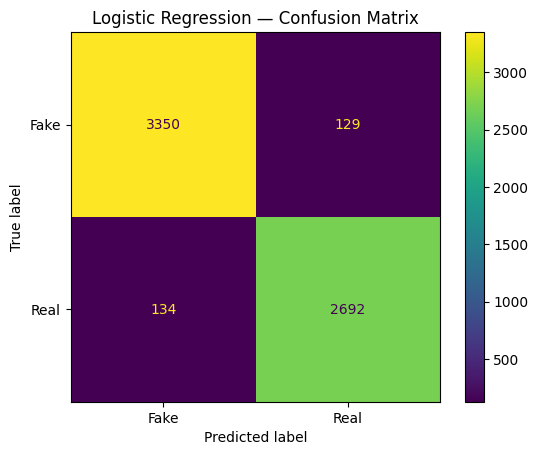

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["Fake", "Real"]
)

disp.plot()

plt.title(
    "Logistic Regression — Confusion Matrix"
)

plt.show()

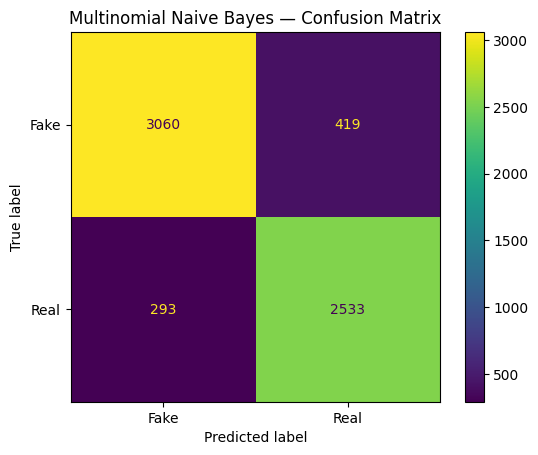

In [ ]:
nb_cm = confusion_matrix(
    y_test,
    nb_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=nb_cm,
    display_labels=["Fake", "Real"]
)

disp.plot()

plt.title(
    "Multinomial Naive Bayes — Confusion Matrix"
)

plt.show()

In [ ]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_real_probability
)

lr_auc = roc_auc_score(
    y_test,
    lr_real_probability
)

In [ ]:
nb_fpr, nb_tpr, _ = roc_curve(
    y_test,
    nb_real_probability
)

nb_auc = roc_auc_score(
    y_test,
    nb_real_probability
)

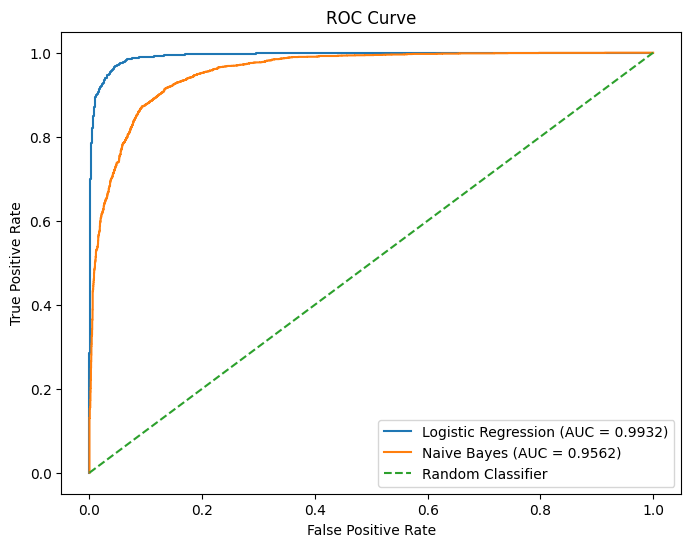

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.4f})"
)

plt.plot(
    nb_fpr,
    nb_tpr,
    label=f"Naive Bayes (AUC = {nb_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
comparison_plot = comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
]

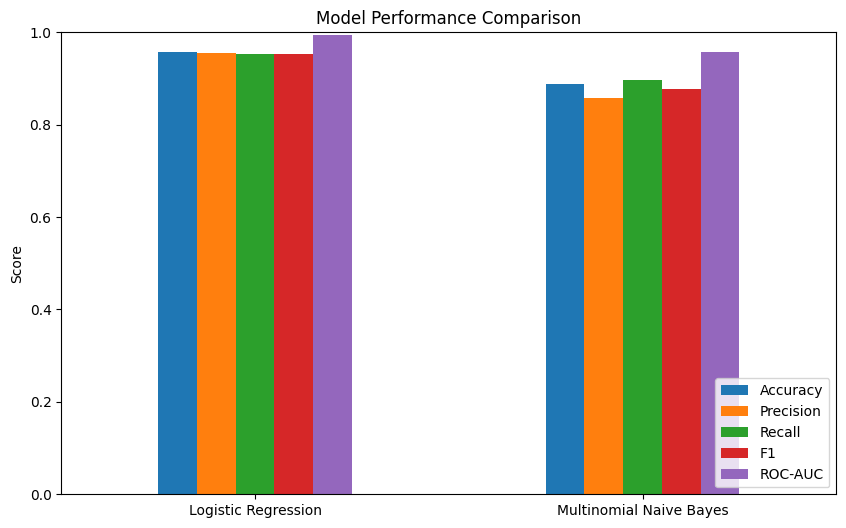

In [ ]:
comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.show()

In [ ]:
error_df = pd.DataFrame({
    "title": df.loc[X_test.index, "title"].values,
    "text": df.loc[X_test.index, "text"].values,
    "actual": y_test.values,
    "predicted_lr": lr_pred,
    "lr_real_probability": lr_real_probability,
    "predicted_nb": nb_pred,
    "nb_real_probability": nb_real_probability
})

In [ ]:
error_df.head()

,title,text,actual,predicted_lr,lr_real_probability,predicted_nb,nb_real_probability
0,BOOM! Hey Democrats….Why The Violent Riots? YO...,Watch:You want a #JobsReport?Here's a jobs rep...,1,1,0.991106,1,0.988339
1,U.S. military orders additional probe into Aug...,WASHINGTON (Reuters) - The head of U.S. forces...,0,0,0.029136,0,0.004828
2,Democrats fail to block Arctic reserve oil dri...,WASHINGTON (Reuters) - U.S. Senate Democrats o...,0,0,0.044286,0,0.004876
3,Secret Documents Reveal Connection Between Pla...,In the immediate aftermath of the shooting at ...,1,1,0.864687,1,0.899034
4,ARMY VETERAN’S Incredible Thanksgiving Smack D...,"On this Thanksgiving, I would like to address ...",1,1,0.948868,1,0.999352


In [ ]:
lr_errors = error_df[
    error_df["actual"] != error_df["predicted_lr"]
].copy()

print(
    "Logistic Regression errors:",
    len(lr_errors)
)

Logistic Regression errors: 263


In [ ]:
lr_false_negatives = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted_lr"] == 1)
].copy()

In [ ]:
display(
    lr_false_negatives[
        [
            "title",
            "lr_real_probability"
        ]
    ].head(20)
)

,title,lr_real_probability
31,Syria's war: How did we get here?,0.512543
41,2017 Has Seen a Terror Attack Attempted in Eur...,0.613868
108,Defense Attorney: Illegal Alien Rockville Rape...,0.564347
229,Lester Holt: presidential debate moderator and...,0.667523
269,Jeopardy’s Ken Jennings Mocks Barron Trump’s R...,0.658270
317,Steven Tyler Lands in Israel Ahead of Aerosmit...,0.534670
325,Here's how moms get pushed out of the workforce,0.511343
385,Obama's Remarks on 'Most Peaceful' World Ring ...,0.609421
441,Who Won the Debate? Donald Trump Avoids Annihi...,0.513530
445,WikiLeaks: CIA Hackers Want to Take Control of...,0.566218


In [ ]:
lr_false_positives = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted_lr"] == 0)
].copy()

In [ ]:
display(
    lr_false_positives[
        [
            "title",
            "lr_real_probability"
        ]
    ].head(20)
)

,title,lr_real_probability
38,BREAKING: SCHIZOPHRENIC COMMANDER IN CHIEF Sen...,0.136523
66,ALABAMA ABC AFFILIATE Can’t Find One Voter Who...,0.432426
181,(VIDEO) FEC CHAIRWOMAN WON’T DROP EFFORT TO RE...,0.462930
223,BREAKING! Trump Moves To Withdraw US From TPP:...,0.223738
356,If anyone doubts Bernie Sanders would've crush...,0.193614
380,NaN,0.489272
424,"MI GOP CHAIR, RONNA ROMNEY-MCDANIEL Chooses Ow...",0.488264
432,Accurate AI Machine Predicts Trump Presidency,0.385055
506,THEIR EVIL KNOWS NO BOUNDS: TALIBAN EXECUTES 5...,0.486425
521,U.S. Intel Finds And Maps Out ISIS Propaganda/...,0.403977


In [ ]:
high_confidence_fake_as_real = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted_lr"] == 1) &
    (error_df["lr_real_probability"] > 0.90)
].sort_values(
    "lr_real_probability",
    ascending=False
)

In [ ]:
display(
    high_confidence_fake_as_real[
        [
            "title",
            "lr_real_probability"
        ]
    ].head(20)
)

,title,lr_real_probability
6080,Judicial Watch: Huma Abedin Emails Show Favors...,0.972367
3356,Obama veers left,0.957900
729,Davi to Hollywood Elite: Invite Illegal Aliens...,0.918053
2617,Fake Hate Crime Blames Trump-Supporting ’White...,0.916680


In [ ]:
display(
    high_confidence_fake_as_real[
        [
            "title",
            "lr_real_probability"
        ]
    ].head(20)
)

,title,lr_real_probability
6080,Judicial Watch: Huma Abedin Emails Show Favors...,0.972367
3356,Obama veers left,0.957900
729,Davi to Hollywood Elite: Invite Illegal Aliens...,0.918053
2617,Fake Hate Crime Blames Trump-Supporting ’White...,0.916680


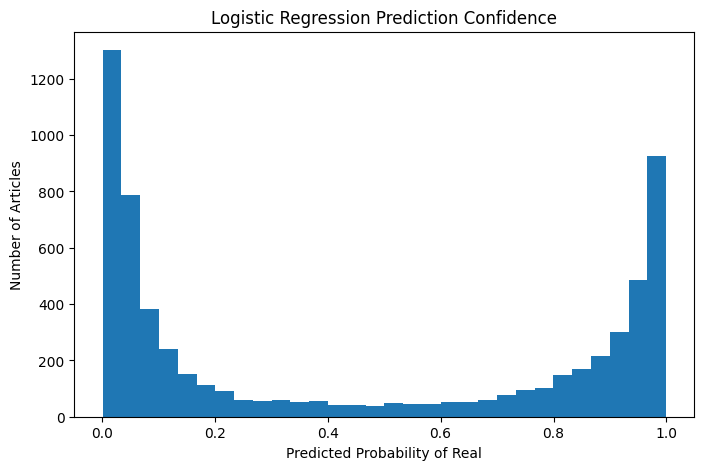

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    lr_real_probability,
    bins=30
)

plt.xlabel(
    "Predicted Probability of Real"
)

plt.ylabel(
    "Number of Articles"
)

plt.title(
    "Logistic Regression Prediction Confidence"
)

plt.show()

In [ ]:
comparison.to_csv(
    "model_comparison.csv"
)

In [ ]:
lr_errors.to_csv(
    "logistic_regression_errors.csv",
    index=False
)

In [ ]:
best_model = lr_model

In [ ]:
if lr_metrics["F1"] >= nb_metrics["F1"]:
    best_model = lr_model
    best_model_name = "Logistic Regression"
else:
    best_model = nb_model
    best_model_name = "Multinomial Naive Bayes"

print(
    "Selected model:",
    best_model_name
)

Selected model: Logistic Regression


In [ ]:
with open(
    "best_model.pkl",
    "wb"
) as file:

    pickle.dump(
        best_model,
        file
    )

In [ ]:
with open(
    "model_metadata.pkl",
    "wb"
) as file:

    pickle.dump(
        {
            "model_name": best_model_name,
            "feature_type": "TF-IDF",
            "max_features": 60000,
            "ngram_range": (1, 2),
            "min_df": 2,
            "max_df": 0.95,
            "sublinear_tf": True
        },
        file
    )